In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from sklearn.datasets import make_blobs

np.random.seed(42)

# Prerequisites

- Technical
  - **Python programing**
  - **Numpy skills**
- Theoretical
  - **Linear Algebra**: Understanding of matrix operations such as multiplication, transpositions, inverse...
  - **Calculus**: Partial derivatives and the Chain Rule for deriving the Gradient Descent update rules for each model.
  - **Statistics**: MSE (Mean squared error), variance, bias, and the normal distribution of errors.
  - **Optimization**: Cost function and how to minimize it iteratively.

# Introduction

## 1. What are regression models?
Regression is a branch of supervised machine learning that predicts a continuous scalar output. It estimates the relationship between a set of independent variables (features) and a dependent variable (target).

## 2. What problem do they solve?
They solve the problem of mapping inputs to real-world outputs. Mathematically, they try to find $h(x)$ that best describes or approximates the underlying layout and trend of the data while ignoring the noise.

## 3. Real world applications
- **Finance**: Predicting stock prices, real estate valuations or future revenue based on historical trends.

- **Healthcare**: Estimating a patient's blood pressure or life expectancy based on biometric data.

- **Engineering**: Predicting the remaining useful life of a battery or the fuel efficiency of a vehicle design.

- **E-commerce**: Forecasting demand for produts to optimize supply chain inventory.

## 4. When vs When not to use
| **Scenario** | **Use Regression When...** | **Avoid Regression When...** |
| :--- | :--- | :--- |
|Target Variable Type|The output you are predicting is continuous and numerical .|The output is categorical or discrete.|
|Relationship Intent|You need to quantify the impact of a feature.|You only care about grouping similar data points together without a specific target.|
|Data Range|You are predicting values within the range of your training data.|You need to predict values far into the future or outside known bounds.|
|Interpretability|You need a "White Box" model where you can explain the weights assigned to each feature.|The relationship is so complex and high-dimensional that simple coefficients cannot capture it.|
|Model Assumptions|The relationship between features and target is relatively stable and additive.|The data is highly non-linear or unstructured (e.g., images, audio, or natural language text).|
|Data Quality|You have a clear dependent variable and want to minimize the residual error.|There is no clear ground truth target variable to train the model against (Unsupervised Learning).|


# Regression
Regression analysis is a statistical modeling technique used to estimate relationships between a dependent variable (target) and one or more independent variables (predictors).

## Mathematical formulation
Let there be a set of points: $ \{ (x_{i},y_{i}) \in R^{2}  i=1...m \}$.

Linear regression is finding a function $h$ such that: $$h(x_{i}) \approx y_{i}  \forall i \in \{1 ... m\}$$ or $$y_{i} = h(x_{i}) + e_{i} \forall i \in \{1 ... m\}$$

$y_{i}$: the dependent variable<br>
$x_{i}$: the independent variable<br>
$h$: the hypothesis function<br>
$e_{i}$: The error between the prediction and the real value

## General goal from regression models

All regression types work by attempting to minimize the error between observed data points and the predicted values, often referred to as residuals, for this purpose we find a multiple solutions, the two most common being:

- Gradient descent: an iterative optimization algorithm used to minimize a cost function by updating model parameters in the direction of the steepest descent.
- OLS (Ordinary least squares): Finds the line that minimizes the sum of squared differences between data points and the line.



# I. Simple linear regression

## 1.Formulation

hypothesis function: $$h(x) = w_0 + w_1x$$
cost function: $$J(w_{0},w_{1})=\frac{1}{2m}\sum_{i=0}^{m}(h(x_{i})-y_{i})^{2} = \frac{1}{2m}\sum_{i=0}^{m}(w_{0}+ w_{1}x_{i}-y_{i})^{2}$$

## 2. Gradient descent

To minimize the cost function $J(w_{0},w_{1})$ using this method, we have to calculate its partial derivatives with respect to $w_0$ and $w_1$:

$$ \frac{\delta J(w_{0},w_{1})}{\delta w_{0}}=\frac{1}{m}\sum_{i=0}^{m}(w_{0}+ w_{1}x_{i}-y_{i}) $$

$$ \frac{\delta J(w_{0},w_{1})}{\delta w_{1}}=\frac{1}{m}\sum_{i=0}^{m}(w_{0}+ w_{1}x_{i}-y_{i})x_{i} $$
For each iteration update the weights using:
$$ w_{0}\leftarrow w_{0}- \alpha\frac{\delta J(w_{0},w_{1})}{\delta w_{0}}$$
$$ w_{1}\leftarrow w_{1}- \alpha\frac{\delta J(w_{0},w_{1})}{\delta w_{1}}$$

$\alpha$: learning rate

## 3. OLS (Ordinary least squares)

For simple linear regression, we get the following solution:
$$ w_{1}=\frac{\sum_{i=0}^{m}(x_{i}-\overline{x})(y_{i}-\overline{y})}{\sum_{i=0}^{m}(x_{i}-\overline{x})^2} $$

$$w_{0}=\overline{y}-w_{1}\overline{x}$$

$\overline{x}$: the mean value of all elements $x_i$<br>
$\overline{y}$: the mean value of all elements $y_i$

In the matricial form, we have:
$$w = (X^{T}X)^{-1}X^{T}Y $$

with:

$w=[w_{1},w_{2}]$

$X=[[1,x_{1}],[1,x_{2}],...,[1,x_{m}]]$

$Y=[y_{1}, y_{2},...,y_{m}]$

In [ ]:
class SimpleLinearRegression:
  def __init__(self, X, Y, alpha=0.001, max_iter=1000):
    self.X = X
    self.Y = Y
    self.w0 = 1.0
    self.w1 = 1.0
    self.max_iter = max_iter
    self.alpha = alpha
    self.cost_update = np.array([])

  def cost(self):
    return np.sum((self.predict(X) - self.Y) ** 2)/ 2 * len(X)

  def predict(self, x):
    return self.w0 + self.w1 * x

  def gradient_descent(self):
    for i in range(self.max_iter):
      d0 = np.sum(self.predict(self.X) - Y)/len(self.X)
      d1 = np.sum((self.predict(self.X) - Y) * X)/len(self.X)
      self.w0 = self.w0 - self.alpha * d0
      self.w1 = self.w1 - self.alpha * d1
      self.cost_update = np.append(self.cost_update, self.cost())

  def ols(self):
    X_mean = np.mean(self.X)
    Y_mean = np.mean(self.Y)
    self.w1 = np.sum((self.X - X_mean) * (self.Y - Y_mean))/np.sum((self.X - X_mean))
    self.w0 = Y_mean - self.w1 * X_mean

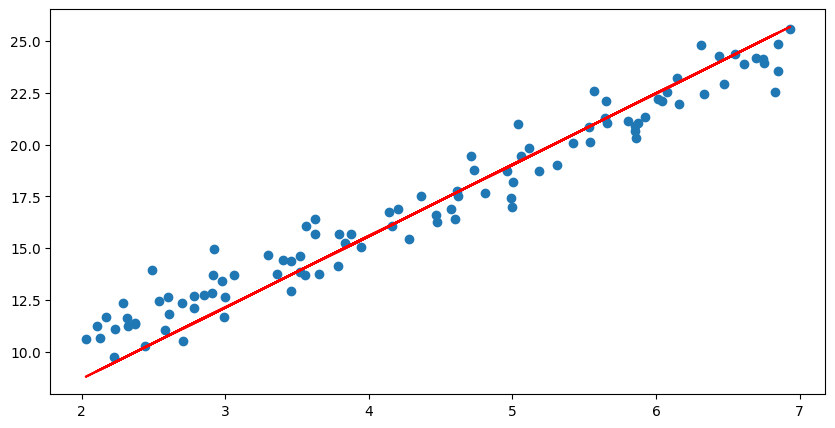

In [ ]:
# Example
X = 2 + 5 * np.random.rand(100, 1)
Y = 4 + 3 * X + np.random.randn(100, 1)

model = SimpleLinearRegression(X, Y)
model.gradient_descent()

plt.figure(figsize=(10, 5))
plt.scatter(X, Y)
plt.plot(X, model.predict(X), color='red')

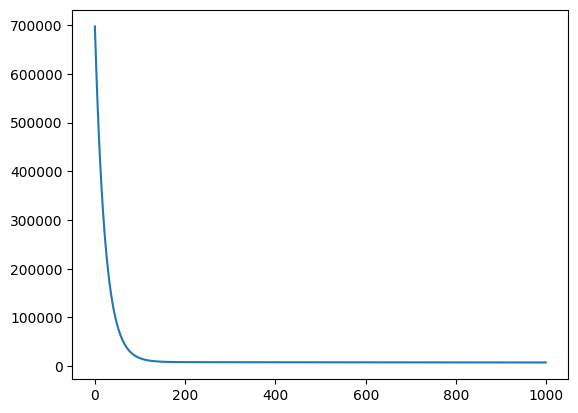

In [ ]:
# show how the cost function updates over the 100 iterations
plt.plot(model.cost_update)

# II. Multiple Linear Regression

This method estimates how several independent factors together influence a single outcome. It fits a straight-line equation to data points to reveal how each variable contributes when the others are held steady.

## 1.Formulation

hypothesis function: $$h(w_0,..., w_p) = \hat{y} = w_0 + \sum_{p=1}^{n}w_px_p = w_0 + w_1x_1 + ... + w_nx_n = W^{T}X$$
cost function: $$J(w_0,..., w_p)=\frac{1}{2m}\sum_{i=0}^{m}(\hat{y}-y_{i})^{2}$$

## 2. Gradient descent
To minimize the cost function $J(w_0,..., w_p)$ using this method, we have to calculate its partial derivatives with respect to each weight $w_p$:

$$\frac{\delta J}{\delta w_p} = \frac{1}{m}\sum_{i=0}^{m}(\hat{y} - y_i)x_p$$
$$\frac{\delta J}{\delta w_0} = \frac{1}{m}\sum_{i=0}^{m}(\hat{y} - y_i)$$

- Gradient for weight $w_p$:
$$ w_{p}\leftarrow w_{p}- \alpha\frac{\delta J}{\delta w_p}$$
- Gradient for bias:
$$ w_{0}\leftarrow w_{0}- \alpha\frac{\delta J}{\delta w_0}$$

## 3. OLS (Ordinary least squares)

For this method we're going to use the matricial formulation because we need to solve p + 1 equations (for each weight $w_p$):

$$\hat{W} = (X^{T}X)^{-1}X^{T}Y$$

In [ ]:
class MultipleLinearRegression:
  def __init__(self, X, Y, alpha=0.001, max_iter=1000):
    self.X = X
    self.Y = Y
    self.b = .0
    self.W = np.zeros(X.shape[1])
    self.alpha = alpha
    self.max_iter = max_iter
    self.cost_updates = []

  def hyp(self):
    return np.dot(self.X, self.W) + self.b

  def cost(self):
    return np.sum((self.hyp() - self.Y) ** 2)/(2 * len(self.Y))

  def gradient_descent(self):
    m = len(Y)
    for i in range(self.max_iter):
      errors = self.hyp() - self.Y
      dW = (self.X.T @ errors)/m
      db = np.sum(errors)/m
      self.W -= self.alpha * dW
      self.b -= self.alpha * db
      self.cost_updates.append(self.cost())

  def ols(self):
    X_bias = np.c_[np.ones(self.X.shape[0]), self.X]
    weights = np.dot(
        np.linalg.inv(X_bias.T @ X_bias),
        X_bias.T @ self.Y
    )
    self.b = weights[0]
    self.W = weights[1:]

  def predict(self, x):
    return self.b + np.dot(x, self.W)

21.688808772619442 21.702487598329327


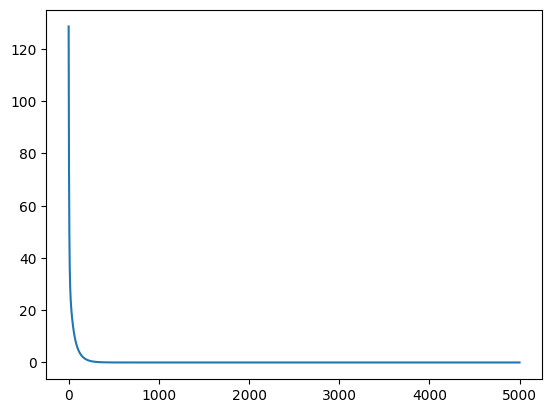

In [ ]:
# Multiple regression example
X = 10 * np.random.rand(10, 3)
Y = np.dot(X, [3., -1., .5])

model = MultipleLinearRegression(X, Y, max_iter=5000)
model.gradient_descent()

print(model.predict(X[0]), Y[0])
# Visualizing the evolution of the cost function
plt.plot(model.cost_updates)

# III. Polynomial Regression

It is a specific type of basis function regression (which will be covered later), that is widely used to fit non-linear relationship to the data (curved patterns).
It is still a linear model because it is linear in its parameters (coefficients).

## 1. Formulation

hypothesis function:
$$h(x) = w_0 + \sum_{i=0}^{n}w_ix^{i} = w_0 + w_1x^1 + ... + w_mx^m$$

cost function:
$$J(w_0,..., w_m)=\frac{1}{2m}\sum_{i=0}^{m}(\hat{y}-y_{i})^{2}$$

## 2. Gradient Descent
To minimize the cost function $J(w_0,..., w_m)$ using this method, we have to calculate its partial derivatives with respect to each weight $w_p$:

$$\frac{\delta J}{\delta w_m} = \frac{1}{m}\sum_{i=0}^{m}(\hat{y} - y_i)x_i^m$$
$$\frac{\delta J}{\delta w_0} = \frac{1}{m}\sum_{i=0}^{m}(\hat{y} - y_i)$$

- Gradient for weight $w_m$:
$$ w_{m}\leftarrow w_{m}- \alpha\frac{\delta J}{\delta w_m}$$
- Gradient for bias:
$$ w_{0}\leftarrow w_{0}- \alpha\frac{\delta J}{\delta w_0}$$

## 3. OLS (Ordinary least squares)

For this method we're going to use the matricial formulation because we need to solve m + 1 equations (for each weight $w_m$):

$$\hat{W} = (X^{T}X)^{-1}X^{T}Y$$

In [ ]:
class PolynomialRegression:
  def __init__(self, X, Y, degree=2, alpha=0.001, max_iter=1000):
    self.degree = degree
    self.X = self._expand_poly_features(X)
    self.Y = Y.flatten()
    self.b = .0
    self.W = np.zeros(self.X.shape[1])
    self.alpha = alpha
    self.max_iter = max_iter
    self.cost_updates = []

  def _expand_poly_features(self, X):
    X_expanded = X
    for i in range(2, self.degree + 1):
      X_expanded = np.c_[X_expanded, X ** i]
    return X_expanded

  def hyp(self):
    return self.b + self.X @ self.W

  def cost(self):
    return np.sum((self.hyp() - self.Y) ** 2)/(2 * len(self.Y))

  def gradient_descent(self):
    m = len(self.Y)
    for i in range(self.max_iter):
      errors = self.hyp() - self.Y
      dW = (self.X.T @ errors)/m
      db = np.sum(errors)/m
      self.W -= self.alpha * dW
      self.b -= self.alpha * db
      self.cost_updates.append(self.cost())

  def ols(self):
    X_bias = np.c_[np.ones(self.X.shape[0]), self.X]
    weights = np.dot(
        np.linalg.inv(X_bias.T @ X_bias),
        X_bias.T @ self.Y
    )
    self.b = weights[0]
    self.W = weights[1:]

  def predict(self, x):
    return self.b + self._expand_poly_features(x) @ self.W

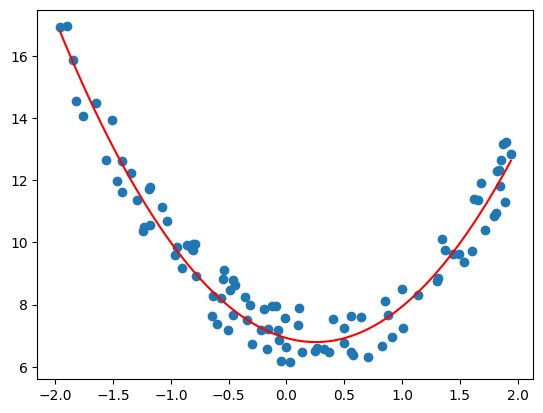

In [ ]:
X = -4 * np.random.rand(100, 1) + 2
Y = 2 * X**2 - X + 6 + 2 * np.random.rand(100, 1)

model = PolynomialRegression(X, Y, degree=2, alpha=0.01, max_iter=1000)
model.gradient_descent()

plt.scatter(X, Y)
x_line = np.linspace(min(X), max(X), 100).reshape(-1, 1)
y_line = model.predict(x_line)

plt.plot(x_line, y_line, color='red')

# IV. Logistic Regression

A type of regression that used for binary classification (predicting one of two outcomes, like yes or no) by calculating probabilities using a sigmoid function:

$$\Phi(z) = \frac{1}{1 + e^{-z}}$$
## 1. Formulation

- hypothesis function: $$h(x) = \frac{1}{1 + e^{-(w_0 + w_1x + ... + w_mx)}}$$
In the case of logistic regression, the Least Squared Error will result in a non-convex loss function. To preserve the convex nature for the loss function, a log loss error function has been designed for logistic regression. The cost function is split for two cases y=1 and y=0.

- loss function:
$$
f(x) = \begin{cases}
    -log(h(x)) & \text{if } y = 1 \\
    -log(1 - h(x)) & \text{if } y = 0
   \end{cases}
$$

- cost function:
$$J(w_0, w_1) = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]$$

$\hat{y}_i$: the prediction for element $i$ in training data.

## 2. Gradient Descent

Partial derivatives of the cost function:
$$\frac{\delta J}{\delta w_m} = \frac{1}{m}\sum_{i=0}^{m}(\hat{y_i} - y_i)x_i^{(m)}$$
$$\frac{\delta J}{\delta w_0} = \frac{1}{m}\sum_{i=0}^{m}(\hat{y_i} - y_i)$$

- Gradient for weight $w_p$:
$$ w_{p}\leftarrow w_{m}- \alpha\frac{\delta J}{\delta w_m}$$
- Gradient for bias:
$$ w_{0}\leftarrow w_{0}- \alpha\frac{\delta J}{\delta w_0}$$

Unlike Linear regression, the derivative of the Logistic regression is non-linear, so the Ordinary Least Squares method won't work, we must use an iterative method like Gradient Descent or Newton's method.

In [ ]:
class LogisticRegression:
  def __init__(self, X, Y, alpha=0.001, max_iter=1000):
    self.X = X
    self.Y = Y
    self.W = np.zeros(self.X.shape[1])
    self.b = .0
    self.alpha = alpha
    self.max_iter = max_iter
    self.cost_updates = []

  def sigmoid(self, z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

  def predict_prob(self, X=None):
    X = self.X if X is None else X
    return self.sigmoid(X @ self.W + self.b)

  def predict(self, X=None, threshold=0.5):
    return (self.predict_prob(X) >= threshold).astype(int)

  def cost(self):
    p = np.clip(self.predict_prob(), 1e-15, 1 - 1e-15)
    return -np.sum(
        self.Y * np.log(p) + \
        (1 - self.Y) * np.log(1-p)
        )/len(self.Y)

  def gradient_descent(self):
    m = len(self.Y)
    for i in range(self.max_iter):
      errors = self.predict_prob() - self.Y
      dW = (self.X.T @ errors)/m
      db = np.sum(errors)/m
      self.W -= self.alpha * dW
      self.b -= self.alpha * db
      self.cost_updates.append(self.cost())

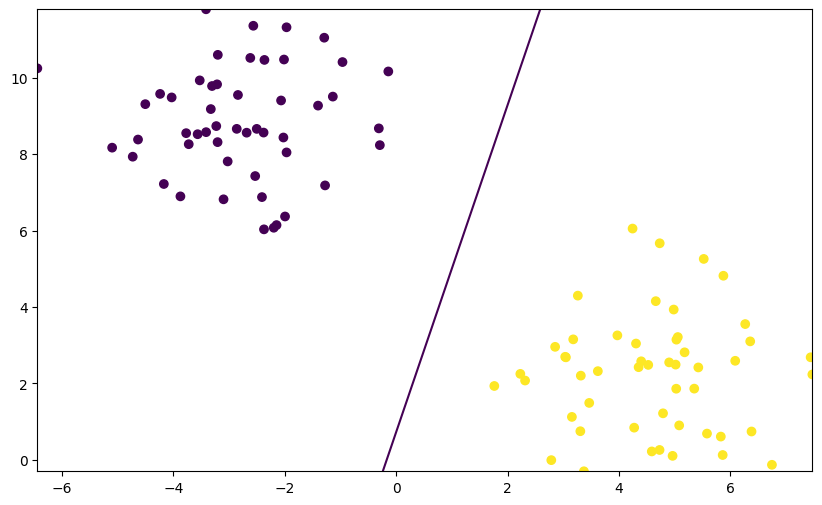

In [ ]:
X, Y = make_blobs(n_samples=100, centers=2, n_features=2, random_state=42, cluster_std=1.5)

# print(X, Y)
model = LogisticRegression(X, Y, alpha=0.1, max_iter=2000)
model.gradient_descent()

plt.figure(figsize=(10, 6))
feature_0 = X[:, 0]
feature_1 = X[:, 1]

plt.scatter(feature_0, feature_1, c=Y)

f0_range = np.linspace(min(feature_0), max(feature_0), 100)
f1_range = np.linspace(min(feature_1), max(feature_1), 100)
f0, f1 = np.meshgrid(f0_range, f1_range)

plt.contour(f0, f1, model.predict_prob(np.c_[f0.ravel(), f1.ravel()]).reshape(f0.shape), levels=[0.5])

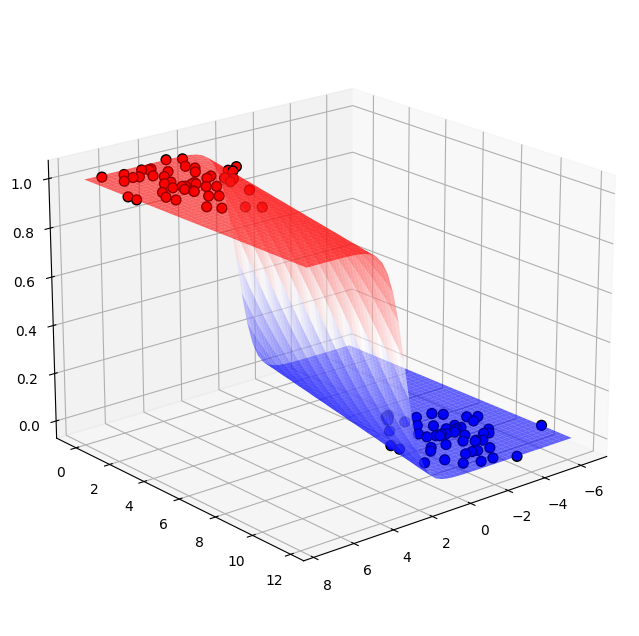

In [ ]:
X, Y = make_blobs(n_samples=100, centers=2, n_features=2, random_state=42, cluster_std=1.5)
model = LogisticRegression(X, Y, alpha=0.1, max_iter=2000)
model.gradient_descent()

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

f0_range = np.linspace(X[:, 0].min(), X[:, 0].max(), 50)
f1_range = np.linspace(X[:, 1].min(), X[:, 1].max(), 50)
f0, f1 = np.meshgrid(f0_range, f1_range)

X_mesh = np.c_[f0.ravel(), f1.ravel()]
probs = model.predict_prob(X_mesh).reshape(f0.shape)

surf = ax.plot_surface(f0, f1, probs, cmap='bwr', alpha=0.6)

ax.scatter(X[:, 0], X[:, 1], Y, c=Y, cmap='bwr', edgecolor='k', s=50, alpha=1)

decision_plane = np.full(f0.shape, 0.5)

ax.view_init(elev=20, azim=50)

# V. Basis Function Regression

Basis function regression is a generalized framework that includes ordinary linear regression as a special base case, where the output is modeled as a linear combination (weighted sum) of the original input features.
This would work only if the true relationship between inputs and outputs is linear.

To handle non-linearity, we introduce basis functions to transform the input features to capture their non-linear relationships, for example in Polynomial regression we've introduced polynomial functions as basis functions:
$$Φ(x) = [1, x, x^2, ..., x^d]$$
and the model is defined as:
$$y = w_0 + w_1x + w_2x^2 +...+ w_dx^d$$

## 1.Formulation
- Hypothesis function
$$h(x) = w_0 + w_1\Phi_1(x) + w_2\Phi_2(x) +...+ w_k\Phi_k(x)$$
- Cost function
$$J(w_0,..., w_m)=\frac{1}{2m}\sum_{i=0}^{m}(h(x_i)-y_{i})^{2}$$

## 2. Gradient Descent
- Partial derivatives of the cost function:
$$\frac{\delta J}{\delta w_m} = \frac{1}{m}\sum_{i=0}^{m}(\hat{y_i} - y_i)\Phi_i(x)$$
$$\frac{\delta J}{\delta w_0} = \frac{1}{m}\sum_{i=0}^{m}(\hat{y_i} - y_i)$$

- Gradient for weight $w_k$:
$$ w_{k}\leftarrow w_{k}- \alpha\frac{\delta J}{\delta w_k}$$
- Gradient for bias:
$$ w_{0}\leftarrow w_{0}- \alpha\frac{\delta J}{\delta w_0}$$

In [ ]:
class BasisFunctionRegression:
  def __init__(self, X, Y, b_fts, alpha=0.001, max_iter=1000):
    self.X = X
    self.Y = Y
    self.b_fts = b_fts
    self.W = np.zeros(len(b_fts))
    self.b = .0
    self.alpha = alpha
    self.max_iter = max_iter
    self.cost_updates = []

  def Phi(self, X):
    return np.column_stack([f(X).flatten() for f in self.b_fts])

  def predict(self, X=None):
    X = self.X if X is None else (X.reshape(-1, 1) if X.ndim == 1 else X)
    return self.b + self.Phi(X) @ self.W

  def cost(self):
    return np.sum((self.predict() - self.Y) ** 2)/(2 * len(self.Y))

  def gradient_descent(self):
    m = len(self.Y)
    phi_matrix = self.Phi(self.X)

    for i in range(self.max_iter):
      errors = phi_matrix @ self.W + self.b - self.Y
      dW = (phi_matrix.T @ errors)/m
      db = np.sum(errors)/m
      self.W -= self.alpha * dW
      self.b -= self.alpha * db
      self.cost_updates.append(self.cost())

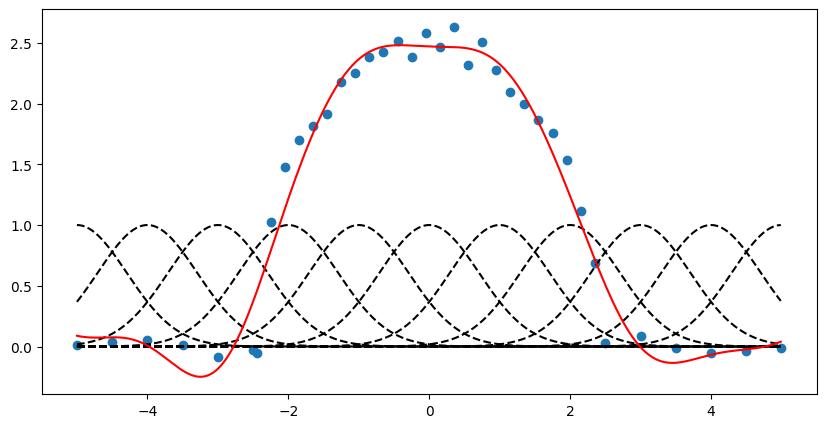

In [ ]:
# Example with Gaussian Basis functions
X = np.arange(-math.sqrt(6), math.sqrt(6), 0.2)
X_ext = np.arange(-5, -math.sqrt(6), 0.5)
Y_ext = np.random.normal(0, 0.05, len(X_ext))
X_extended = np.concatenate((X, -X_ext, X_ext))
Y = np.array([math.sqrt(6 - _ ** 2) for _ in X]) + np.random.normal(0, 0.1, len(X))
Y_extended = np.concatenate((Y, Y_ext, -Y_ext))

# Gaussian basis functions
basis_fcts = [
    lambda x, m=i: np.exp(-(x-m)**2 / (2 * 0.5))
    for i in range(-5, 6)
]

model = BasisFunctionRegression(X_extended, Y_extended, np.array(basis_fcts), alpha=0.01, max_iter=10000)
model.gradient_descent()

x = np.arange(-5, 5, 0.01)
y_pred = model.predict(x)

plt.figure(figsize=(10, 5))
plt.scatter(X_extended, Y_extended)
for f in basis_fcts:
  plt.plot(x, f(x), linestyle='--', color='black')
plt.plot(x, y_pred, color='red')